In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the dataset

work_place_df = pd.read_excel('workplace_accident_data.xlsx')

# print the first five(5) rows of the dataset

work_place_df.head()

,company_name,location,gender,age_in_years,collection_date_and_time,type_of_testing,declared_medication,alcohol_result,breath_test_result_1,breath_test_result_2,company_cut_off_level,drug_result,drugs_non_negative,lab_result
0,Company 868,Location 4,Male,18,2020-01-02 02:19:08,Oral Fluid (Drugs Only),no,Pass,0.0,0.0,0.35,Negative,NaN,Negative
1,Company 556,Location 9,Female,57,2020-01-03 01:13:17,Oral Fluid (Back to Lab & Breath),no,Pass,0.0,0.0,0.09,Negative,NaN,Negative
2,Company 208,Location 2,Male,31,2020-01-03 02:43:58,Oral Fluid (Back to Lab Only),no,Pass,0.0,0.0,0.35,Negative,NaN,Positive
3,Company 540,Location 5,Female,23,2020-01-06 08:42:01,Urine (Drugs Only),no,Pass,0.0,0.0,0.35,Negative,NaN,Negative
4,Company 986,Location 1,Male,54,2020-01-07 02:43:46,Breath Only,no,Pass,0.0,0.0,0.35,Negative,NaN,Negative


In [3]:
work_place_df.isnull().sum()

company_name                  0
location                      0
gender                        0
age_in_years                  0
collection_date_and_time      0
type_of_testing               0
declared_medication           0
alcohol_result                0
breath_test_result_1          0
breath_test_result_2          0
company_cut_off_level         0
drug_result                   0
drugs_non_negative          917
lab_result                    0
dtype: int64

In [4]:
work_place_df2 = work_place_df.copy()
work_place_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   company_name              1000 non-null   object        
 1   location                  1000 non-null   object        
 2   gender                    1000 non-null   object        
 3   age_in_years              1000 non-null   int64         
 4   collection_date_and_time  1000 non-null   datetime64[ns]
 5   type_of_testing           1000 non-null   object        
 6   declared_medication       1000 non-null   object        
 7   alcohol_result            1000 non-null   object        
 8   breath_test_result_1      1000 non-null   float64       
 9   breath_test_result_2      1000 non-null   float64       
 10  company_cut_off_level     1000 non-null   float64       
 11  drug_result               1000 non-null   object        
 12  drugs_non_negative   

In [5]:
work_place_df2['drugs_non_negative'].fillna('unknown',inplace=True)

C:\Users\MIDE\AppData\Local\Temp\ipykernel_3440\3915284717.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  work_place_df2['drugs_non_negative'].fillna('unknown',inplace=True)


In [6]:
work_place_df2.isnull()

,company_name,location,gender,age_in_years,collection_date_and_time,type_of_testing,declared_medication,alcohol_result,breath_test_result_1,breath_test_result_2,company_cut_off_level,drug_result,drugs_non_negative,lab_result
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
work_place_df2.describe()

,age_in_years,collection_date_and_time,breath_test_result_1,breath_test_result_2,company_cut_off_level
count,1000.000000,1000,1000.000000,1000.000000,1000.000000
mean,41.376000,2021-12-21 23:02:23.277999872,0.075766,0.075766,0.178660
min,18.000000,2020-01-02 02:19:08,0.000000,0.000000,0.090000
25%,29.000000,2021-01-04 21:40:23.500000,0.000000,0.000000,0.090000
50%,42.000000,2021-12-10 05:37:19,0.000000,0.000000,0.090000
75%,54.000000,2022-12-09 13:04:49.249999872,0.000000,0.000000,0.350000
max,64.000000,2023-12-28 00:01:42,1.450599,1.450599,0.350000
std,13.936529,NaN,0.256622,0.256622,0.123313


In [8]:
# Check unique values of all columns except 'Description' column
for x in work_place_df2.columns:
    if x != 'Description':
      print('--'*30); print(f'Unique values of "{x}" column'); print('--'*30)
      print(work_place_df2[x].unique())
      print('\n')

------------------------------------------------------------
Unique values of "company_name" column
------------------------------------------------------------
['Company 868' 'Company 556' 'Company 208' 'Company 540' 'Company 986'
 'Company 622' 'Company 586' 'Company 124' 'Company 903' 'Company 699'
 'Company 1000' 'Company 185' 'Company 516' 'Company 452' 'Company 597'
 'Company 126' 'Company 251' 'Company 740' 'Company 698' 'Company 640'
 'Company 181' 'Company 859' 'Company 606' 'Company 424' 'Company 97'
 'Company 646' 'Company 137' 'Company 283' 'Company 315' 'Company 861'
 'Company 938' 'Company 807' 'Company 415' 'Company 286' 'Company 551'
 'Company 839' 'Company 445' 'Company 397' 'Company 841' 'Company 557'
 'Company 420' 'Company 222' 'Company 393' 'Company 108' 'Company 533'
 'Company 408' 'Company 886' 'Company 898' 'Company 799' 'Company 374'
 'Company 328' 'Company 873' 'Company 824' 'Company 999' 'Company 447'
 'Company 100' 'Company 261' 'Company 260' 'Company 246' '

In [9]:
# Convert date column to datetime and extract features
work_place_df2['collection_date_and_time'] = pd.to_datetime(work_place_df2['collection_date_and_time'])
work_place_df2['year'] = work_place_df2['collection_date_and_time'].dt.year
work_place_df2['month'] = work_place_df2['collection_date_and_time'].dt.month
work_place_df2['day_of_week'] = work_place_df2['collection_date_and_time'].dt.day
work_place_df2['weekOfYear'] = work_place_df2['collection_date_and_time'].dt.isocalendar().week
work_place_df2['hour'] = work_place_df['collection_date_and_time'].dt.hour
work_place_df2['minutes'] = work_place_df2['collection_date_and_time'].dt.minute
work_place_df2['seconds'] = work_place_df2['collection_date_and_time'].dt.second


work_place_df2

,company_name,location,gender,age_in_years,collection_date_and_time,type_of_testing,declared_medication,alcohol_result,breath_test_result_1,breath_test_result_2,...,drug_result,drugs_non_negative,lab_result,year,month,day_of_week,weekOfYear,hour,minutes,seconds
0,Company 868,Location 4,Male,18,2020-01-02 02:19:08,Oral Fluid (Drugs Only),no,Pass,0.00000,0.00000,...,Negative,unknown,Negative,2020,1,2,1,2,19,8
1,Company 556,Location 9,Female,57,2020-01-03 01:13:17,Oral Fluid (Back to Lab & Breath),no,Pass,0.00000,0.00000,...,Negative,unknown,Negative,2020,1,3,1,1,13,17
2,Company 208,Location 2,Male,31,2020-01-03 02:43:58,Oral Fluid (Back to Lab Only),no,Pass,0.00000,0.00000,...,Negative,unknown,Positive,2020,1,3,1,2,43,58
3,Company 540,Location 5,Female,23,2020-01-06 08:42:01,Urine (Drugs Only),no,Pass,0.00000,0.00000,...,Negative,unknown,Negative,2020,1,6,2,8,42,1
4,Company 986,Location 1,Male,54,2020-01-07 02:43:46,Breath Only,no,Pass,0.00000,0.00000,...,Negative,unknown,Negative,2020,1,7,2,2,43,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Company 559,Location 5,Female,19,2023-12-21 15:28:27,Oral Fluid (Back to Lab Only),yes,Pass,0.00000,0.00000,...,Negative,unknown,Positive,2023,12,21,51,15,28,27
996,Company 663,Location 8,Male,32,2023-12-23 13:36:43,Urine (Back to Lab & Breath),no,Pass,0.00000,0.00000,...,Negative,unknown,Negative,2023,12,23,51,13,36,43
997,Company 175,Location 3,Female,52,2023-12-26 11:05:51,Urine (with Alcohol),no,Pass,1.13341,1.13341,...,Non-Negative,Cannabis,Positive,2023,12,26,52,11,5,51
998,Company 499,Location 3,Male,56,2023-12-27 02:22:38,Oral Fluid (Drugs Only),no,Pass,0.00000,0.00000,...,Negative,unknown,Negative,2023,12,27,52,2,22,38


In [10]:
# Drop one of the highly correlated columns
work_place_df2 = work_place_df2.drop(columns=['breath_test_result_2'])


In [11]:
# Rename the remaining column for clarity if needed (optional)
work_place_df2.rename(columns={'breath_test_result_1': 'breath_test_result'}, inplace=True)
work_place_df2.head()

,company_name,location,gender,age_in_years,collection_date_and_time,type_of_testing,declared_medication,alcohol_result,breath_test_result,company_cut_off_level,drug_result,drugs_non_negative,lab_result,year,month,day_of_week,weekOfYear,hour,minutes,seconds
0,Company 868,Location 4,Male,18,2020-01-02 02:19:08,Oral Fluid (Drugs Only),no,Pass,0.0,0.35,Negative,unknown,Negative,2020,1,2,1,2,19,8
1,Company 556,Location 9,Female,57,2020-01-03 01:13:17,Oral Fluid (Back to Lab & Breath),no,Pass,0.0,0.09,Negative,unknown,Negative,2020,1,3,1,1,13,17
2,Company 208,Location 2,Male,31,2020-01-03 02:43:58,Oral Fluid (Back to Lab Only),no,Pass,0.0,0.35,Negative,unknown,Positive,2020,1,3,1,2,43,58
3,Company 540,Location 5,Female,23,2020-01-06 08:42:01,Urine (Drugs Only),no,Pass,0.0,0.35,Negative,unknown,Negative,2020,1,6,2,8,42,1
4,Company 986,Location 1,Male,54,2020-01-07 02:43:46,Breath Only,no,Pass,0.0,0.35,Negative,unknown,Negative,2020,1,7,2,2,43,46


In [12]:
work_place_df_new= work_place_df2.drop(columns =['collection_date_and_time'])

In [13]:
work_place_df_new.head()

,company_name,location,gender,age_in_years,type_of_testing,declared_medication,alcohol_result,breath_test_result,company_cut_off_level,drug_result,drugs_non_negative,lab_result,year,month,day_of_week,weekOfYear,hour,minutes,seconds
0,Company 868,Location 4,Male,18,Oral Fluid (Drugs Only),no,Pass,0.0,0.35,Negative,unknown,Negative,2020,1,2,1,2,19,8
1,Company 556,Location 9,Female,57,Oral Fluid (Back to Lab & Breath),no,Pass,0.0,0.09,Negative,unknown,Negative,2020,1,3,1,1,13,17
2,Company 208,Location 2,Male,31,Oral Fluid (Back to Lab Only),no,Pass,0.0,0.35,Negative,unknown,Positive,2020,1,3,1,2,43,58
3,Company 540,Location 5,Female,23,Urine (Drugs Only),no,Pass,0.0,0.35,Negative,unknown,Negative,2020,1,6,2,8,42,1
4,Company 986,Location 1,Male,54,Breath Only,no,Pass,0.0,0.35,Negative,unknown,Negative,2020,1,7,2,2,43,46


In [14]:
positive_results_df = work_place_df_new[(work_place_df_new['lab_result'] == "Positive")]

# Print the first few rows as a list of lists (columns and rows)
print(positive_results_df.head(1).values.tolist())

[['Company 208', 'Location 2', 'Male', 31, 'Oral Fluid (Back to Lab Only)', 'no', 'Pass', 0.0, 0.35, 'Negative', 'unknown', 'Positive', 2020, 1, 3, 1, 2, 43, 58]]


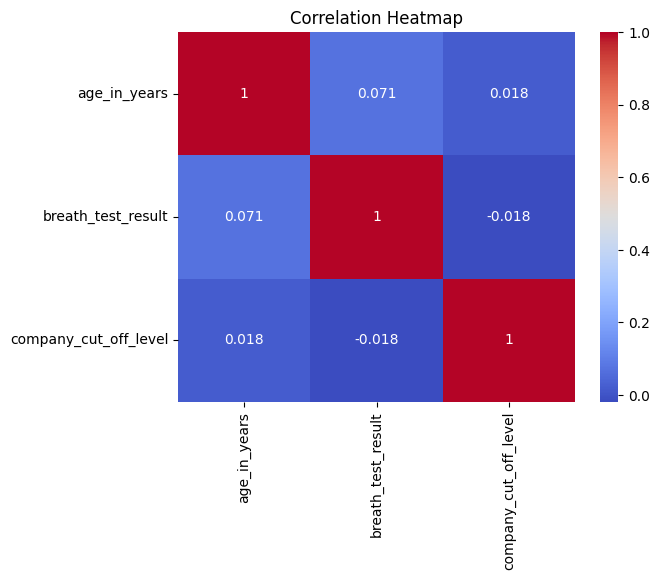

In [15]:
# Select only numeric columns
numeric_cols = work_place_df2.select_dtypes(include=['float64', 'int64'])

# Compute correlation
correlation = numeric_cols.corr()

# Plot heatmap
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The correlation analysis revealed that the columns breath_test_result_1 and breath_test_result_2 exhibit a perfect correlation of 1.0. This indicates that both columns contain identical values, making one of them redundant for analysis.

To address this redundancy and avoid potential multicollinearity in our machine learning model, the two columns will be merged into a single column. This ensures that the dataset remains efficient and avoids overrepresentation of the same information.

The merging process involves retaining only one of the two columns while discarding the other. Since both columns contain identical values, the choice of which column to keep is arbitrary and does not impact the analysis.

In [16]:
work_place_df_new.head(40)

,company_name,location,gender,age_in_years,type_of_testing,declared_medication,alcohol_result,breath_test_result,company_cut_off_level,drug_result,drugs_non_negative,lab_result,year,month,day_of_week,weekOfYear,hour,minutes,seconds
0,Company 868,Location 4,Male,18,Oral Fluid (Drugs Only),no,Pass,0.000000,0.35,Negative,unknown,Negative,2020,1,2,1,2,19,8
1,Company 556,Location 9,Female,57,Oral Fluid (Back to Lab & Breath),no,Pass,0.000000,0.09,Negative,unknown,Negative,2020,1,3,1,1,13,17
2,Company 208,Location 2,Male,31,Oral Fluid (Back to Lab Only),no,Pass,0.000000,0.35,Negative,unknown,Positive,2020,1,3,1,2,43,58
3,Company 540,Location 5,Female,23,Urine (Drugs Only),no,Pass,0.000000,0.35,Negative,unknown,Negative,2020,1,6,2,8,42,1
4,Company 986,Location 1,Male,54,Breath Only,no,Pass,0.000000,0.35,Negative,unknown,Negative,2020,1,7,2,2,43,46
5,Company 622,Location 8,Male,50,Urine (Drugs Only),no,Pass,0.000000,0.35,Negative,unknown,Negative,2020,1,10,2,16,25,41
6,Company 586,Location 1,Female,58,Oral Fluid (Drugs Only),no,Pass,0.000000,0.35,Negative,unknown,Negative,2020,1,12,2,16,51,59
7,Company 124,Location 1,Male,35,Urine (Drugs Only),no,Pass,0.000000,0.09,Negative,unknown,Negative,2020,1,13,3,1,34,8
8,Company 903,Location 1,Female,60,Oral Fluid (Back to Lab Only),no,Pass,0.000000,0.09,Negative,unknown,Positive,2020,1,14,3,9,48,11
9,Company 699,Location 8,Female,33,Oral Fluid (Drugs & Breath),yes,Fail,0.000000,0.09,Negative,unknown,Negative,2020,1,15,3,1,52,52


In [17]:
print(work_place_df_new.shape)

(1000, 19)


## Using columntransformer()

In [18]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [19]:
work_place_df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   company_name           1000 non-null   object 
 1   location               1000 non-null   object 
 2   gender                 1000 non-null   object 
 3   age_in_years           1000 non-null   int64  
 4   type_of_testing        1000 non-null   object 
 5   declared_medication    1000 non-null   object 
 6   alcohol_result         1000 non-null   object 
 7   breath_test_result     1000 non-null   float64
 8   company_cut_off_level  1000 non-null   float64
 9   drug_result            1000 non-null   object 
 10  drugs_non_negative     1000 non-null   object 
 11  lab_result             1000 non-null   object 
 12  year                   1000 non-null   int32  
 13  month                  1000 non-null   int32  
 14  day_of_week            1000 non-null   int32  
 15  weekO

In [38]:
# Check unique values of all columns except 'Description' column
for x in work_place_df_new.columns:
    if x != 'Description':
      print('--'*30); print(f'Unique values of "{x}" column'); print('--'*30)
      print(work_place_df2[x].unique())
      print('\n')

------------------------------------------------------------
Unique values of "company_name" column
------------------------------------------------------------
['Company 868' 'Company 556' 'Company 208' 'Company 540' 'Company 986'
 'Company 622' 'Company 586' 'Company 124' 'Company 903' 'Company 699'
 'Company 1000' 'Company 185' 'Company 516' 'Company 452' 'Company 597'
 'Company 126' 'Company 251' 'Company 740' 'Company 698' 'Company 640'
 'Company 181' 'Company 859' 'Company 606' 'Company 424' 'Company 97'
 'Company 646' 'Company 137' 'Company 283' 'Company 315' 'Company 861'
 'Company 938' 'Company 807' 'Company 415' 'Company 286' 'Company 551'
 'Company 839' 'Company 445' 'Company 397' 'Company 841' 'Company 557'
 'Company 420' 'Company 222' 'Company 393' 'Company 108' 'Company 533'
 'Company 408' 'Company 886' 'Company 898' 'Company 799' 'Company 374'
 'Company 328' 'Company 873' 'Company 824' 'Company 999' 'Company 447'
 'Company 100' 'Company 261' 'Company 260' 'Company 246' '

In [ ]:

# If there are other columns to be fixed, convert them as well:
# df['other_column'] = df['other_column'].astype('desired_dtype')

# Save the modified dataframe back to a new CSV file
work_place_df_new.to_csv('work_place_dataset.csv', index=False)

print("Changes saved to 'work_place_dataset.csv'")


In [20]:
binary_columns = [
    "alcohol_result",
    "declared_medication",
    "drug_result",    
    "gender",
      # assuming it contains binary values like 'Non-Negative/Negative'.
]
numerical_columns = [
    "age_in_years",
    "breath_test_result",
    "company_cut_off_level",
    "year",
    "month",
    "weekOfYear",
    "day_of_week",
    "hour",
    "minutes",
    "seconds"
]
categorical_columns = [
    "type_of_testing",
    "drugs_non_negative"
]


In [21]:
# preprocessing for categorical features (OneHotEncoding)
# List of possible categories for the 'type_of_testing' column
type_of_testing_categories = [
    'Oral Fluid (Drugs Only)',
    'Oral Fluid (Back to Lab & Breath)',
    'Oral Fluid (Back to Lab Only)',
    'Urine (Drugs Only)',
    'Breath Only',
    'Oral Fluid (Drugs & Breath)',
    'Urine (Back to Lab & Breath)',
    'Urine (with Alcohol)',
    'Urine (Drugs & Breath)',
    'Urine (Back to Lab Only)'
]

# List of possible categories for the 'drugs_non_negative' column.
drugs_non_negative_categories = [
    'None',  # Represents no drugs detected
    'Methadone',
    'Cocaine',
    'Tramadol',
    'Amphetamines',
    'Methamphetamine',
    'Ecstasy',
    'Cannabis',
    'Barbiturates',
    'Benzodiazepine',
    'Tri-cyclic Antidepressants',
    'Opiates',
    'Other',  # For any drugs not listed above
]

# Creating an instance of OneHotEncoder for encoding categorical features
# 'drop='first'' means we drop the first category of each feature to avoid multicollinearity (dummy variable trap)
# 'categories' specifies the unique categories to consider for each categorical feature
categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',   # Ignore unknown categories
    categories=[type_of_testing_categories, drugs_non_negative_categories]  # Set explicit categories for encoding
)


In [22]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Preprocessing for numerical features (scaling)
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())  # Standardizes numerical features
])

# Preprocessing for binary features (imputation and encoding)
# Define categories for binary columns
gender_categories = ['Male', 'Female']
declared_categories = ['no', 'yes']
alcohol_result_categories = ['Fail', 'Pass']
drug_result_categories = ['Negative', 'Non-Negative']

# Create a pipeline for binary columns
binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Fills missing values with the most frequent value
    ('encoder', OneHotEncoder(handle_unknown='ignore', categories=[gender_categories, declared_categories, alcohol_result_categories, drug_result_categories]))
])

# Combine preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_columns),  # Apply numerical_transformer to numerical columns
        ('cat', categorical_transformer, categorical_columns),  # Apply categorical_transformer to categorical columns
        ('bin', binary_transformer, binary_columns)  # Apply binary_transformer to binary columns
    ]
)


In [23]:
#pip show scikit-learn

#!pip install --upgrade scikit-learn


### process the data for model testing

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

x = work_place_df_new.drop(columns=['lab_result','company_name','location'])  # Features
y = work_place_df_new['lab_result']                 # Labels
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.2, random_state= 42)

In [25]:
preprocessor.fit(x_train)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['age_in_years', 'breath_test_result',
                                  'company_cut_off_level', 'year', 'month',
                                  'weekOfYear', 'day_of_week', 'hour',
                                  'minutes', 'seconds']),
                                ('cat',
                                 OneHotEncoder(categories=[['Oral Fluid (Drugs '
                                                            'Only)',
                                                            'Oral Fluid (Back '
                                                            'to Lab & Breath)',
                                                            'Oral Fluid (Back '
                                                            'to Lab Only)',
                                                            'Urine (Drugs '...
                                                            'Other']],
                                               handle_unknown='ignore'),
                                 ['type_of_testing', 'drugs_non_negative']),
                                ('bin',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(categories=[['Male',
                                                                             'Female'],
                                                                            ['no',
                                                                             'yes'],
                                                                            ['Fail',
                                                                             'Pass'],
                                                                            ['Negative',
                                                                             'Non-Negative']],
                                                                handle_unknown='ignore'))]),
                                 ['alcohol_result', 'declared_medication',
                                  'drug_result', 'gender'])])

In [26]:
print(preprocessor)


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['age_in_years', 'breath_test_result',
                                  'company_cut_off_level', 'year', 'month',
                                  'weekOfYear', 'day_of_week', 'hour',
                                  'minutes', 'seconds']),
                                ('cat',
                                 OneHotEncoder(categories=[['Oral Fluid (Drugs '
                                                            'Only)',
                                                            'Oral Fluid (Back '
                                                            'to Lab & Breath)',
                                                            'Oral Fluid (Back '
                                                            'to Lab Only)',
                                                            'Urine (Drugs '...
                 

In [27]:
print(x_train.shape)

(800, 16)


In [28]:
x_train_processed = preprocessor.fit_transform(x_train)

In [29]:
print(x_train_processed)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9664 stored elements and shape (800, 41)>
  Coords	Values
  (0, 0)	-1.0126472415294558
  (0, 1)	-0.29612943575764106
  (0, 2)	-0.699827060307702
  (0, 3)	-1.3164900396301131
  (0, 4)	-1.3430796289765434
  (0, 5)	-1.2822531560428574
  (0, 6)	0.5183892644023557
  (0, 7)	1.4730313400530255
  (0, 8)	0.8624650597032478
  (0, 9)	-1.5791024683658312
  (0, 10)	1.0
  (0, 35)	1.0
  (1, 0)	-1.5838063448861595
  (1, 1)	-0.29612943575764106
  (1, 2)	-0.699827060307702
  (1, 3)	0.49001430291551923
  (1, 4)	-1.6363284562639984
  (1, 5)	-1.5523077894071553
  (1, 6)	1.3126382057575379
  (1, 7)	-0.801371694045735
  (1, 8)	-1.158608473205909
  (1, 9)	-1.6363707930719678
  (1, 17)	1.0
  (1, 35)	1.0
  (2, 0)	0.7722249564602429
  :	:
  (797, 35)	1.0
  (798, 0)	-0.5842779140119281
  (798, 1)	-0.29612943575764106
  (798, 2)	-0.699827060307702
  (798, 3)	-0.413237868357297
  (798, 4)	0.7096621620356408
  (798, 5)	0.6081292775072286
  (798, 6)	-0.616

In [30]:
pd.DataFrame(x_train_processed)

,0
0,<Compressed Sparse Row sparse matrix of dtype ...
1,<Compressed Sparse Row sparse matrix of dtype ...
2,<Compressed Sparse Row sparse matrix of dtype ...
3,<Compressed Sparse Row sparse matrix of dtype ...
4,<Compressed Sparse Row sparse matrix of dtype ...
...,...
795,<Compressed Sparse Row sparse matrix of dtype ...
796,<Compressed Sparse Row sparse matrix of dtype ...
797,<Compressed Sparse Row sparse matrix of dtype ...
798,<Compressed Sparse Row sparse matrix of dtype ...


In [31]:
print(x_train_processed.shape)

(800, 41)


In [32]:
# check the datatype of the dataframe
print(pd.DataFrame(x_train_processed).dtypes)

0    object
dtype: object


In [33]:
x_test_processed = preprocessor.transform(x_test)
print(x_test_processed)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2419 stored elements and shape (200, 41)>
  Coords	Values
  (0, 0)	1.4147789477365345
  (0, 1)	-0.29612943575764106
  (0, 2)	-0.699827060307702
  (0, 3)	0.49001430291551923
  (0, 4)	-1.6363284562639984
  (0, 5)	-1.7548487644303787
  (0, 6)	-0.8431803493493852
  (0, 7)	1.0465807711595079
  (0, 8)	1.0308878541123443
  (0, 9)	0.31075224693667314
  (0, 11)	1.0
  (0, 35)	1.0
  (1, 0)	-1.5838063448861595
  (1, 1)	-0.29612943575764106
  (1, 2)	-0.699827060307702
  (1, 3)	0.49001430291551923
  (1, 4)	1.2961598166105506
  (1, 5)	1.2832658609179735
  (1, 6)	0.17799686096442044
  (1, 7)	0.05152944374130014
  (1, 8)	1.0308878541123443
  (1, 9)	0.4252888963489461
  (1, 13)	1.0
  (1, 35)	1.0
  (2, 0)	0.41525051686230313
  :	:
  (198, 0)	-1.5838063448861595
  (198, 1)	0.5287086773697027
  (198, 2)	-0.699827060307702
  (198, 3)	0.49001430291551923
  (198, 4)	-0.4633331471141788
  (198, 5)	-0.3370619392678144
  (198, 6)	1.5395664747161613
  

In [34]:
import joblib

preprocessor_path = "column_transformer.joblib"

# Save the preprocessor using joblib
joblib.dump(preprocessor, preprocessor_path)

print(f"ColumnTransformer saved to {preprocessor_path}")

# Load the preprocessor using joblib
preprocessor_path = "column_transformer.joblib"
loaded_object = joblib.load(preprocessor_path)

print(loaded_object)
print(type(loaded_object))


ColumnTransformer saved to column_transformer.joblib
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['age_in_years', 'breath_test_result',
                                  'company_cut_off_level', 'year', 'month',
                                  'weekOfYear', 'day_of_week', 'hour',
                                  'minutes', 'seconds']),
                                ('cat',
                                 OneHotEncoder(categories=[['Oral Fluid (Drugs '
                                                            'Only)',
                                                            'Oral Fluid (Back '
                                                            'to Lab & Breath)',
                                                            'Oral Fluid (Back '
                                                            'to Lab Only)',
                                           

## Using GridSearch csv

In [35]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
#from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
 
# Define models and their hyperparameter grids
models_and_params = {
    "Random Forest": {
        "model": RandomForestClassifier(),
        "params": {
            "n_estimators": [10, 50, 100, 200],
            "max_depth": [None, 10, 20, 30],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
        },
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(),
        "params": {
            "max_depth": [None, 5, 10, 20, 30],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
        },
    },
    "K-Nearest Neighbors": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": list(range(1, 21)),  # Test 1 to 20 neighbors
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan", "minkowski"],
        },
    },
    "Support Vector Machine": {
        "model": SVC(),
        "params": {
            "C": [0.1, 1, 10, 100],
            "kernel": ["linear", "rbf", "poly", "sigmoid"],
            "gamma": ["scale", "auto"],
        },
    },
    
}


# Perform Grid Search for each model
best_models = {}
for model_name, mp in models_and_params.items():
    print(f"Training {model_name}...")
    grid_search = GridSearchCV(
        estimator=mp["model"],
        param_grid=mp["params"],
        scoring="accuracy",
        cv=5,
        n_jobs=-1,
        verbose=1,
    )
    grid_search.fit(x_train_processed, y_train)
    best_models[model_name] = grid_search.best_estimator_
    print(f"Best parameters for {model_name}: {grid_search.best_params_}")
    print(f"Best cross-validated accuracy for {model_name}: {grid_search.best_score_}\n")

# Evaluate the best models on the test set
print("Evaluating best models on the test set...\n")
for model_name, model in best_models.items():
    y_pred = model.predict(x_test_processed)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{model_name} Test Accuracy: {accuracy:.4f}")

Training Random Forest...
Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best parameters for Random Forest: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validated accuracy for Random Forest: 0.9587499999999999

Training Decision Tree...
Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best parameters for Decision Tree: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 5}
Best cross-validated accuracy for Decision Tree: 0.9574999999999999

Training K-Nearest Neighbors...
Fitting 5 folds for each of 120 candidates, totalling 600 fits


c:\Users\MIDE\Desktop\model deploy\venv\Lib\site-packages\sklearn\model_selection\_search.py:1107: UserWarning: One or more of the test scores are non-finite: [0.82875 0.82875 0.8575  0.82875 0.855   0.85625 0.85375 0.85625 0.86125
 0.86125 0.855   0.865   0.8625  0.86375 0.8525  0.86625 0.85625 0.86
 0.85375 0.8575  0.84875 0.85    0.85125 0.8525  0.85375 0.85375 0.85
 0.85375 0.85    0.85    0.85    0.85    0.85125 0.85125 0.84875 0.85125
 0.85    0.85    0.8475  0.85125     nan 0.87375     nan 0.87375     nan
 0.89625     nan 0.9         nan 0.91125     nan 0.905       nan 0.91125
     nan 0.91        nan 0.8975      nan 0.8925      nan 0.89        nan
 0.88625     nan 0.88375     nan 0.88375     nan 0.88375     nan 0.8825
     nan 0.87375     nan 0.87125     nan 0.87        nan 0.86125 0.82875
 0.82875 0.8575  0.82875 0.855   0.85625 0.85375 0.85625 0.86125 0.86125
 0.855   0.865   0.8625  0.86375 0.8525  0.86625 0.85625 0.86    0.85375
 0.8575  0.84875 0.85    0.85125 0.8525  0.85

Best parameters for K-Nearest Neighbors: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Best cross-validated accuracy for K-Nearest Neighbors: 0.9112500000000001

Training Support Vector Machine...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters for Support Vector Machine: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validated accuracy for Support Vector Machine: 0.9575000000000001

Evaluating best models on the test set...

Random Forest Test Accuracy: 0.9450
Decision Tree Test Accuracy: 0.9500
K-Nearest Neighbors Test Accuracy: 0.9100
Support Vector Machine Test Accuracy: 0.9300


### From gridsearchCV Decision Tree is the model best with high accuracy. time for implementation 

In [36]:
from sklearn.tree import DecisionTreeClassifier
import joblib

# Define the best Decision Tree model using the grid search parameters
best_decision_tree = DecisionTreeClassifier(
    max_depth=None,
    min_samples_leaf=4,
    min_samples_split=2,
    random_state=42  # Ensure reproducibility
)

# Train the best Decision Tree model on the entire training dataset
best_decision_tree.fit(x_train_processed, y_train)

# Save the trained model using joblib
joblib.dump(best_decision_tree, "decision_tree_model.joblib")

print("Decision Tree model saved as 'decision_tree_model.joblib'")


Decision Tree model saved as 'decision_tree_model.joblib'


In [37]:
# Load the saved model
loaded_model = joblib.load("decision_tree_model.joblib")

# Make predictions
y_pred = loaded_model.predict(x_test_processed)
print("Loaded model accuracy:", accuracy_score(y_test, y_pred))


Loaded model accuracy: 0.95
